# Wage Analysis: Polynomial Regression and Step Functions

This notebook analyzes the relationship between age and wage using two different approaches:
1. Polynomial regression with cross-validation for degree selection
2. Step function regression with cross-validation for optimal number of cuts

We'll also perform ANOVA testing to compare different polynomial models.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, KFold
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Set random seed for reproducibility
np.random.seed(42)


## Load and Prepare Data

We'll load the wage dataset and prepare our features (age) and target (wage) variables.

In [3]:
# Load the dataset
data = pd.read_csv('Wage.csv')

# Extract age and wage columns
X = data['age'].values.reshape(-1, 1)  # Feature
y = data['wage'].values  # Target

print("Dataset shape:", data.shape)
print("\nSummary statistics:")
print(data[['age', 'wage']].describe())

Dataset shape: (3000, 11)

Summary statistics:
               age         wage
count  3000.000000  3000.000000
mean     42.414667   111.703608
std      11.542406    41.728595
min      18.000000    20.085537
25%      33.750000    85.383940
50%      42.000000   104.921507
75%      51.000000   128.680488
max      80.000000   318.342430


## Polynomial Regression with Cross-Validation

We'll test polynomial regression models of different degrees (1 to 10) using k-fold cross-validation to find the optimal degree.

Degree 1: MSE = 1675.01
Degree 2: MSE = 1599.60
Degree 3: MSE = 1594.73
Degree 4: MSE = 1593.91
Degree 5: MSE = 1595.43
Degree 6: MSE = 1594.79
Degree 7: MSE = 1593.62
Degree 8: MSE = 1593.95
Degree 9: MSE = 1597.96
Degree 10: MSE = 1606.76

Optimal polynomial degree: 7


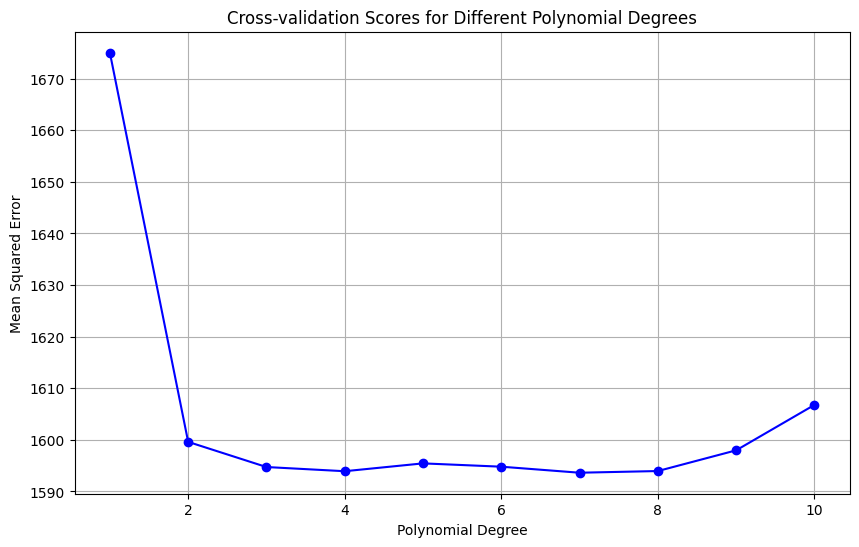

In [4]:
# Function to perform cross-validation for polynomial regression
def polynomial_cv_score(X, y, degree, cv=5):
    poly = PolynomialFeatures(degree=degree)
    X_poly = poly.fit_transform(X)
    model = LinearRegression()
    cv_scores = cross_val_score(model, X_poly, y, cv=cv, scoring='neg_mean_squared_error')
    return -cv_scores.mean()  # Return mean MSE

# Test different polynomial degrees
degrees = range(1, 11)
cv_scores = []

for degree in degrees:
    mse = polynomial_cv_score(X, y, degree)
    cv_scores.append(mse)
    print(f"Degree {degree}: MSE = {mse:.2f}")

# Find optimal degree
optimal_degree = degrees[np.argmin(cv_scores)]
print(f"\nOptimal polynomial degree: {optimal_degree}")

# Plot cross-validation scores
plt.figure(figsize=(10, 6))
plt.plot(degrees, cv_scores, 'bo-')
plt.xlabel('Polynomial Degree')
plt.ylabel('Mean Squared Error')
plt.title('Cross-validation Scores for Different Polynomial Degrees')
plt.grid(True)
plt.show()

## ANOVA Analysis

We'll perform ANOVA testing to compare polynomial models of different degrees and determine which terms are statistically significant.

In [5]:
# Fit the polynomial of optimal degree using statsmodels for ANOVA
poly = PolynomialFeatures(degree=optimal_degree)
X_poly = poly.fit_transform(X)
feature_names = [f'x^{i}' for i in range(optimal_degree + 1)]

# Fit the model using statsmodels
model = sm.OLS(y, X_poly)
results = model.fit()

# Print summary of the model
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.088
Model:                            OLS   Adj. R-squared:                  0.086
Method:                 Least Squares   F-statistic:                     47.90
Date:                Mon, 27 Oct 2025   Prob (F-statistic):           2.26e-56
Time:                        20:09:14   Log-Likelihood:                -15312.
No. Observations:                3000   AIC:                         3.064e+04
Df Residuals:                    2993   BIC:                         3.068e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.6420      2.340      1.129      0.2

## Visualize Polynomial Fit

We'll create a scatter plot of the data and overlay the best-fitting polynomial curve with confidence intervals.

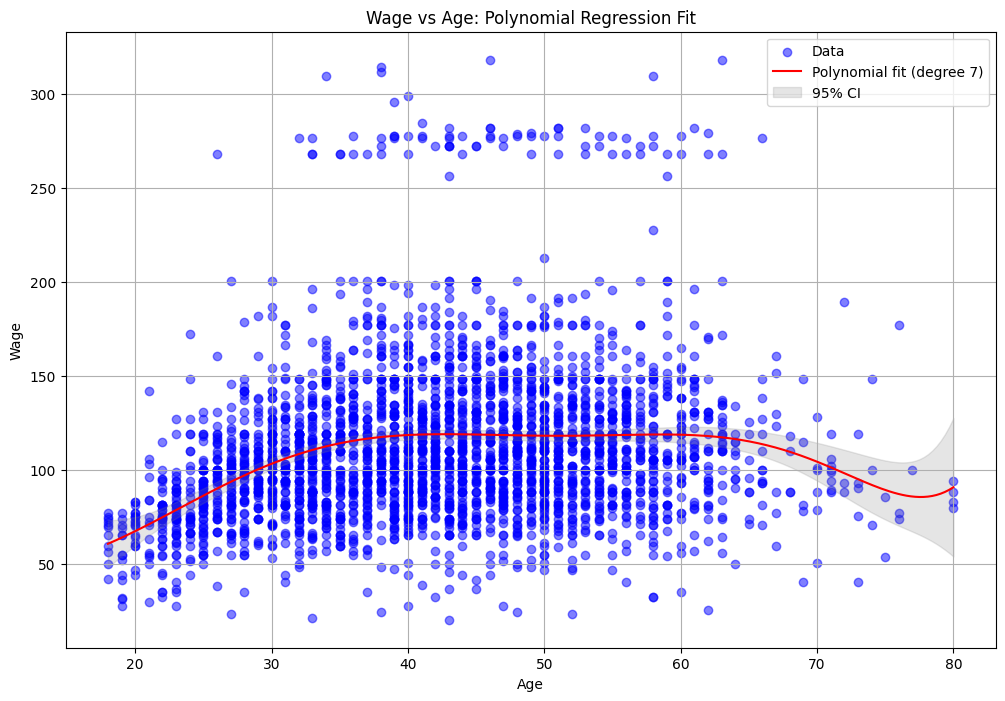

In [6]:
# Create new data points for smooth curve
X_new = np.linspace(X.min(), X.max(), 200).reshape(-1, 1)
X_new_poly = poly.transform(X_new)

# Get predictions and confidence intervals
y_pred = results.get_prediction(X_new_poly)
y_mean = y_pred.predicted_mean
y_ci = y_pred.conf_int()

# Plot the results
plt.figure(figsize=(12, 8))
plt.scatter(X, y, color='blue', alpha=0.5, label='Data')
plt.plot(X_new, y_mean, color='red', label=f'Polynomial fit (degree {optimal_degree})')
plt.fill_between(X_new.ravel(), y_ci[:, 0], y_ci[:, 1], color='gray', alpha=0.2, label='95% CI')
plt.xlabel('Age')
plt.ylabel('Wage')
plt.title('Wage vs Age: Polynomial Regression Fit')
plt.legend()
plt.grid(True)
plt.show()

## Step Function Regression with Cross-Validation

We'll implement a step function regression by creating binary features based on age cutpoints, and use cross-validation to find the optimal number of cuts.

Number of cuts 2: MSE = 1702.94
Number of cuts 3: MSE = 1659.10
Number of cuts 4: MSE = 1641.42
Number of cuts 5: MSE = 1637.54
Number of cuts 6: MSE = 1629.36
Number of cuts 7: MSE = 1623.83
Number of cuts 8: MSE = 1618.93
Number of cuts 9: MSE = 1620.23
Number of cuts 10: MSE = 1616.17
Number of cuts 11: MSE = 1619.59
Number of cuts 12: MSE = 1615.79
Number of cuts 13: MSE = 1612.73
Number of cuts 14: MSE = 1607.76
Number of cuts 15: MSE = 1612.34
Number of cuts 16: MSE = 1611.19
Number of cuts 17: MSE = 1609.57
Number of cuts 18: MSE = 1611.89
Number of cuts 19: MSE = 1616.67
Number of cuts 20: MSE = 1613.05

Optimal number of cuts: 14


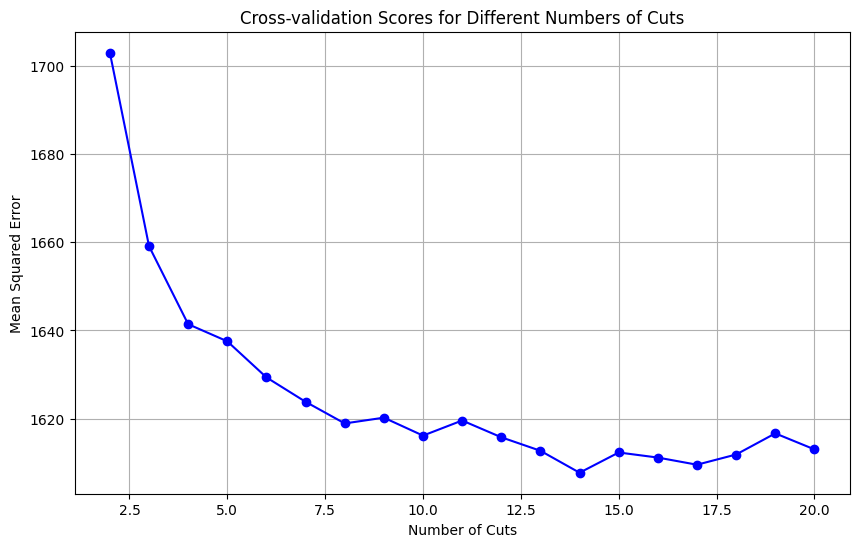

In [7]:
# Function to create step function features
def create_step_features(X, n_cuts):
    return pd.get_dummies(pd.qcut(X.ravel(), n_cuts, duplicates='drop')).values

# Function to perform cross-validation for step function
def step_cv_score(X, y, n_cuts, cv=5):
    try:
        X_step = create_step_features(X, n_cuts)
        model = LinearRegression()
        cv_scores = cross_val_score(model, X_step, y, cv=cv, scoring='neg_mean_squared_error')
        return -cv_scores.mean()
    except ValueError:  # In case of duplicate edges
        return float('inf')

# Test different numbers of cuts
n_cuts_range = range(2, 21)
step_cv_scores = []

for n_cuts in n_cuts_range:
    mse = step_cv_score(X, y, n_cuts)
    step_cv_scores.append(mse)
    print(f"Number of cuts {n_cuts}: MSE = {mse:.2f}")

# Find optimal number of cuts
optimal_cuts = n_cuts_range[np.argmin(step_cv_scores)]
print(f"\nOptimal number of cuts: {optimal_cuts}")

# Plot cross-validation scores
plt.figure(figsize=(10, 6))
plt.plot(n_cuts_range, step_cv_scores, 'bo-')
plt.xlabel('Number of Cuts')
plt.ylabel('Mean Squared Error')
plt.title('Cross-validation Scores for Different Numbers of Cuts')
plt.grid(True)
plt.show()

## Visualize Step Function Fit

We'll create a scatter plot of the data and overlay the optimal step function fit, showing the cutpoints and mean wage within each bin.

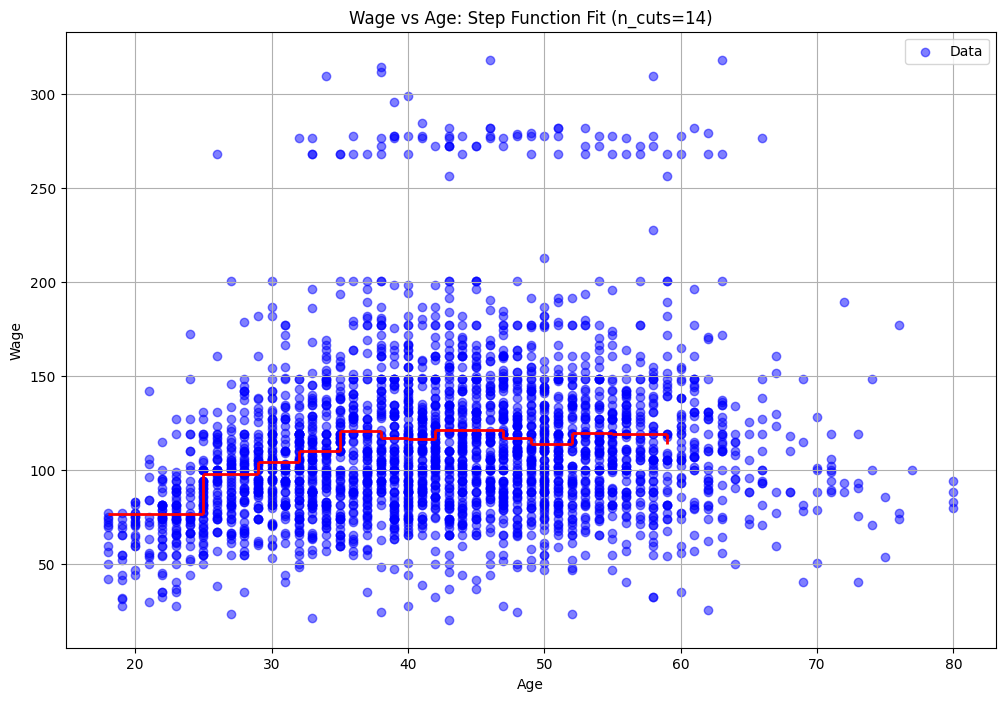

In [8]:
# Fit the optimal step function model
X_step = create_step_features(X, optimal_cuts)
step_model = LinearRegression()
step_model.fit(X_step, y)

# Get the bins and their boundaries
bins = pd.qcut(X.ravel(), optimal_cuts, duplicates='drop')
bin_edges = bins.categories.values
bin_means = [np.mean(y[bins.codes == i]) for i in range(len(bin_edges))]

# Plot the results
plt.figure(figsize=(12, 8))
plt.scatter(X, y, color='blue', alpha=0.5, label='Data')

# Plot step function
for i in range(len(bin_edges) - 1):
    left = bin_edges[i].left
    right = bin_edges[i].right
    plt.hlines(bin_means[i], left, right, color='red', linewidth=2)
    plt.vlines(right, bin_means[i], bin_means[i+1], color='red', linewidth=2)

plt.xlabel('Age')
plt.ylabel('Wage')
plt.title(f'Wage vs Age: Step Function Fit (n_cuts={optimal_cuts})')
plt.legend()
plt.grid(True)
plt.show()